<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/MONTESDEOCA-ANDRES-DL-TP3-Co24.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

## 0. Data and Libraries

In [1]:
# Librerias

import numpy as np
import pandas as pd
import seaborn as sns
import gdown
import zipfile
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


In [2]:
url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = '/content/datos_zip/dataset_emociones/train'
DATASET_ROOT_TEST  = '/content/datos_zip/dataset_emociones/validation' # Lo usaremos como TEST

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=0d1d2e71-9666-48d0-a86f-e239eb865c30
To: /content/archivo.zip
100%|██████████| 40.0M/40.0M [00:00<00:00, 156MB/s]


In [3]:
# Analisis Distribucion de clases

print("--- TRAIN ---")
train_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TRAIN)):
    ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase)
    if os.path.isdir(ruta_clase):
        train_counts[clase] = len(os.listdir(ruta_clase))

total_train = sum(train_counts.values())
for clase, cantidad in train_counts.items():
    porcentaje = (cantidad / total_train) * 100 if total_train > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Train: {total_train}\n")

print("--- TEST ---")
test_counts = {}
for clase in sorted(os.listdir(DATASET_ROOT_TEST)):
    ruta_clase = os.path.join(DATASET_ROOT_TEST, clase)
    if os.path.isdir(ruta_clase):
        test_counts[clase] = len(os.listdir(ruta_clase))

total_test = sum(test_counts.values())
for clase, cantidad in test_counts.items():
    porcentaje = (cantidad / total_test) * 100 if total_test > 0 else 0
    print(f"Clase '{clase}': {cantidad} imágenes ({porcentaje:.2f}%)")
print(f"Total Test: {total_test}")

--- TRAIN ---
Clase 'alegria': 4772 imágenes (38.89%)
Clase 'disgusto': 717 imágenes (5.84%)
Clase 'enojo': 705 imágenes (5.75%)
Clase 'miedo': 281 imágenes (2.29%)
Clase 'seriedad': 2524 imágenes (20.57%)
Clase 'sorpresa': 1290 imágenes (10.51%)
Clase 'tristeza': 1982 imágenes (16.15%)
Total Train: 12271

--- TEST ---
Clase 'alegria': 1185 imágenes (38.62%)
Clase 'disgusto': 160 imágenes (5.22%)
Clase 'enojo': 162 imágenes (5.28%)
Clase 'miedo': 74 imágenes (2.41%)
Clase 'seriedad': 680 imágenes (22.16%)
Clase 'sorpresa': 329 imágenes (10.72%)
Clase 'tristeza': 478 imágenes (15.58%)
Total Test: 3068


- Dividido 80/20, bien estratificado por clase
- La distribucion de las clases no es homogenea

## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



- Weighted Random Sampler: Oversample en el DataLoader
- Class Weights: Penalizacion en la fucnion de perdida, mayor en clases minoritoarias

### 1.1 Visializador de Imagenes

--- DICCIONARIO DE CLASES ---
0: Aleatorio
1: Alegria
2: Disgusto
3: Enojo
4: Miedo
5: Seriedad
6: Sorpresa
7: Tristeza
----------------------------------------
Opción 0 (o inválida). Clase elegida al azar.
--- METADATA DE LAS IMÁGENES (TRISTEZA) ---
[1] Archivo: train_06827_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[2] Archivo: train_02793_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[3] Archivo: train_05081_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG
[4] Archivo: train_01253_aligned.jpg | Resolución: (100, 100) | Modo: RGB | Formato: JPEG


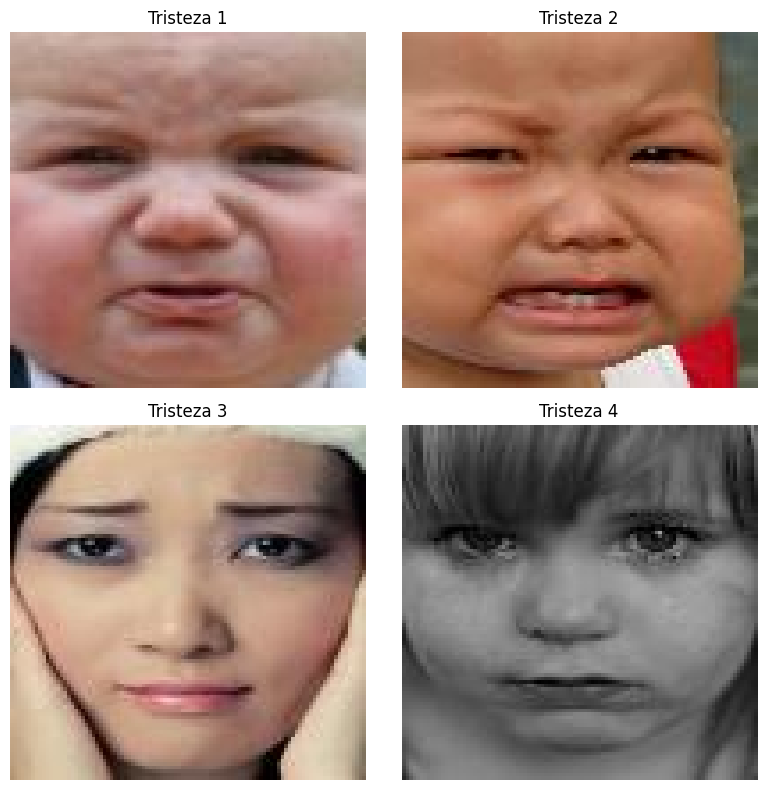

In [4]:
# VISUALIZADOR
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Clases ordenadas alfabéticamente
clases = sorted(os.listdir(DATASET_ROOT_TRAIN))

# Crear y mostrar el diccionario de opciones
diccionario_clases = {i+1: c for i, c in enumerate(clases)}
print("--- DICCIONARIO DE CLASES ---")
print("0: Aleatorio")
for k, v in diccionario_clases.items():
    print(f"{k}: {v.capitalize()}")
print("-" * 40)

# @markdown Ingresa el número de la clase que deseas visualizar:
opcion_clase = 0 # @param {type:"integer"}

if 1 <= opcion_clase <= len(clases):
    clase_seleccionada = diccionario_clases[opcion_clase]
else:
    clase_seleccionada = random.choice(clases)
    print("Opción 0 (o inválida). Clase elegida al azar.")

ruta_clase = os.path.join(DATASET_ROOT_TRAIN, clase_seleccionada)
imagenes_disponibles = [f for f in os.listdir(ruta_clase) if os.path.isfile(os.path.join(ruta_clase, f))]

if imagenes_disponibles:
    # Seleccionar hasta 4 imágenes aleatorias
    cantidad_a_mostrar = min(4, len(imagenes_disponibles))
    imagenes_random = random.sample(imagenes_disponibles, cantidad_a_mostrar)

    print(f"--- METADATA DE LAS IMÁGENES ({clase_seleccionada.upper()}) ---")

    # Crear una cuadrícula de 2x2
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten() # Aplanar para iterar fácilmente

    for i in range(4):
        if i < cantidad_a_mostrar:
            imagen_random = imagenes_random[i]
            ruta_imagen = os.path.join(ruta_clase, imagen_random)
            img = Image.open(ruta_imagen)

            print(f"[{i+1}] Archivo: {imagen_random} | Resolución: {img.size} | Modo: {img.mode} | Formato: {img.format}")

            # Mostrar la imagen con matplotlib
            if img.mode == 'L':
                axes[i].imshow(img, cmap='gray')
            else:
                axes[i].imshow(img)

            axes[i].set_title(f"{clase_seleccionada.capitalize()} {i+1}")

        axes[i].axis('off') # Ocultar ejes incluso si no hay imagen en ese espacio

    plt.tight_layout()
    plt.show()
else:
    print(f"No se encontraron imágenes en la clase {clase_seleccionada}.")

- Imagenes de rostros en primer plano
- Todas las imágenes son 100x100 pixels, 3ch(RGB) y formato JPEG
- Algunas en escalas de grises
- Algunas con el lienzo que no es de 100*100

### 1.2 Transformaciones y Data Agumentation

In [5]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import torch
import numpy as np

# 1. Definir Transformaciones (BASELINE: SIN DATA AUGMENTATION)
train_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# El test set NUNCA lleva Data Augmentation
test_transforms = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

# 2. Cargar los Datasets
train_dataset = datasets.ImageFolder(root=DATASET_ROOT_TRAIN, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=DATASET_ROOT_TEST, transform=test_transforms)

# 3. Calcular Pesos para el Sampler (Oversampling)
targets = train_dataset.targets
class_counts = np.bincount(targets)

# El peso de cada muestra es inversamente proporcional a la frecuencia de su clase
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

# Crear el WeightedRandomSampler
# num_samples asegura que cada época tenga la misma cantidad total de imágenes que el dataset original
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(targets), replacement=True)

# 4. Crear los DataLoaders (TRAIN LLEVA SAMPLER EN LUGAR DE SHUFFLE)
batch_size = 64
# Al usar sampler, NO se puede usar shuffle=True al mismo tiempo
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Clases mapeadas: {train_dataset.class_to_idx}")
print(f"Imágenes para entrenamiento: {len(train_dataset)} -> Batches: {len(train_loader)}")
print(f"Imágenes para test: {len(test_dataset)} -> Batches: {len(test_loader)}")
print("\n¡BASELINE CONFIGURADO: OVERSAMPLING (WRS) SIN DATA AUGMENTATION!")

Clases mapeadas: {'alegria': 0, 'disgusto': 1, 'enojo': 2, 'miedo': 3, 'seriedad': 4, 'sorpresa': 5, 'tristeza': 6}
Imágenes para entrenamiento: 12271 -> Batches: 192
Imágenes para test: 3068 -> Batches: 48

¡BASELINE CONFIGURADO: OVERSAMPLING (WRS) SIN DATA AUGMENTATION!


## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

In [6]:
import numpy as np
import torch.nn as nn
import torch

# Bloque de convolución para emplear en la red
def conv_block(c_in, c_out, k=3, p=1, s=1, pk=2):
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        nn.ReLU(),
        nn.MaxPool2d(pk)
    )

class EmotionCNN(nn.Module):
    def __init__(self, filtros=[16, 32, 64]):
        super(EmotionCNN, self).__init__()
        # La entrada es de 3 canales (RGB) y de 100x100 píxeles

        layers = []
        in_channels = 3

        # Construir dinámicamente las capas convolucionales
        for out_channels in filtros:
            layers.append(conv_block(in_channels, out_channels))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        # Calcular automáticamente el tamaño de la imagen tras los MaxPool2d
        dim = 100
        for _ in filtros:
            dim = dim // 2

        flatten_size = filtros[-1] * dim * dim

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Dropout para reducir el overfitting
            nn.Linear(512, 7)   # 7 clases de emociones
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nModelo base listo para instanciar en el dispositivo: {device}")


Modelo base listo para instanciar en el dispositivo: cuda


In [7]:
!pip install wandb -qU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 102.9 MB/s eta 0:00:00


In [8]:
import wandb
from google.colab import userdata

wandb_key = userdata.get('WANDB_API_KEY')
wandb.login(key=wandb_key)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amontesdeoca1982 (andresmontesdeoca) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import time
import wandb
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import f1_score
import torch

num_epochs = 100
patience = 7

# Diccionario con las 3 configuraciones de Baseline solicitadas
experimentos_baseline = {
    "Baseline_WRS_small": [16, 32, 64],
    "Baseline_WRS_mid": [32, 64, 128],
    "Baseline_WRS_large": [64, 128, 256]
}

print("Iniciando batería de entrenamientos BASELINE (Oversampling, sin Data Augmentation)...\n")

# Definimos el grupo para WandB. Esto permitirá agrupar estas 3 corridas en la UI.
# Cuando probemos Data Augmentation, se llamará "DA_atributo" (ej: DA_rotacion)
grupo_experimento = "Baseline_WRS"

for nombre_corrida, lista_filtros in experimentos_baseline.items():
    print("="*60)
    print(f"EXPERIMENTO: {nombre_corrida} | Arquitectura: {lista_filtros}")
    print("="*60)

    # Instanciar el modelo con la arquitectura correspondiente
    modelo = EmotionCNN(filtros=lista_filtros).to(device)

    # CUIDADO: Como usamos Oversampling (WRS) en el DataLoader,
    # NO usamos pesos en la función de costo (Double Dipping).
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(modelo.parameters(), lr=0.001)

    best_test_loss = float('inf')
    epochs_no_improve = 0
    best_epoch = 0
    best_metrics = {}
    run_metrics_history = [] # <-- LISTA EN MEMORIA: Evita enviar datos "basura" de la fase de early stopping a W&B

    # Inicializar W&B
    # Usamos el parámetro 'group' para agrupar los experimentos
    wandb.init(
        project="tp3-clasificador-emociones",
        name=nombre_corrida,
        group=grupo_experimento, # Agrupa las corridas visualmente en la interfaz de W&B
        config={
            "epochs": num_epochs,
            "patience": patience,
            "learning_rate": 0.001,
            "filtros": lista_filtros,
            "batch_size": 64,
            "class_weights": False,
            "data_augmentation": False,
            "focal_loss": False,
            "oversampling": True,
            "grupo": grupo_experimento
        }
    )

    for epoch in range(num_epochs):
        start_time = time.time()

        # --- FASE DE ENTRENAMIENTO ---
        modelo.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        all_train_preds = []
        all_train_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = modelo(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        epoch_train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')

        # --- FASE DE TEST ---
        modelo.eval()
        running_test_loss = 0.0
        correct_test = 0
        total_test_loop = 0
        all_test_preds = []
        all_test_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = modelo(inputs)
                loss = criterion(outputs, labels)

                running_test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_test_loop += labels.size(0)
                correct_test += (predicted == labels).sum().item()

                all_test_preds.extend(predicted.cpu().numpy())
                all_test_labels.extend(labels.cpu().numpy())

        epoch_test_loss = running_test_loss / len(test_loader.dataset)
        epoch_test_acc = correct_test / total_test_loop
        epoch_test_f1 = f1_score(all_test_labels, all_test_preds, average='macro')

        end_time = time.time()
        print(f"Ep {epoch+1:02d} | Tiempo: {end_time - start_time:.1f}s | Tr_Loss: {epoch_train_loss:.4f} | Tr_Acc: {epoch_train_acc:.4f} | Te_Loss: {epoch_test_loss:.4f} | Te_Acc: {epoch_test_acc:.4f} | Te_F1: {epoch_test_f1:.4f}")

        # Guardar métricas en memoria en lugar de enviarlas directo a WandB.
        # Esto permite que si la época 10 fue la mejor, y corta en la 17,
        # solo enviemos a wandb hasta la 10, manteniendo los gráficos perfectos.
        metricas_epoca = {
            "epoch": epoch + 1,
            "train_loss": round(epoch_train_loss, 2),
            "train_acc": round(epoch_train_acc, 2),
            "train_f1_macro": round(epoch_train_f1, 2),
            "test_loss": round(epoch_test_loss, 2),
            "test_acc": round(epoch_test_acc, 2),
            "test_f1_macro": round(epoch_test_f1, 2)
        }
        run_metrics_history.append(metricas_epoca)

        # --- EARLY STOPPING ---
        if epoch_test_loss < best_test_loss:
            best_test_loss = epoch_test_loss
            epochs_no_improve = 0
            best_epoch = epoch + 1
            best_metrics = metricas_epoca
            # Guardamos el mejor modelo físicamente con un nombre atado al experimento actual
            torch.save(modelo.state_dict(), f'best_model_{nombre_corrida}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"-> EarlyStopping disparado tras {epoch+1} épocas.")
                break

    print(f"\nCargando los pesos del mejor modelo (Época {best_epoch}) para {nombre_corrida}...")
    modelo.load_state_dict(torch.load(f'best_model_{nombre_corrida}.pth'))

    print(f"Logueando métricas en W&B solamente hasta la mejor época ({best_epoch}) para evitar la cola descendente...")
    # Aquí enviamos todo de una sola vez a W&B truncando la lista en la mejor época
    for metricas in run_metrics_history[:best_epoch]:
        wandb.log(metricas)

    if wandb.run is not None:
        # Forzamos los valores del summary de W&B para que reflejen la mejor época exacta
        for key, val in best_metrics.items():
            wandb.run.summary[key] = val

        # Subimos el artefacto (.pth) directamente asociado a este run
        wandb.save(f'best_model_{nombre_corrida}.pth')

    wandb.finish()
    print(f"¡Entrenamiento de {nombre_corrida} finalizado!\n")

print("¡TODOS LOS EXPERIMENTOS BASELINE HAN FINALIZADO!")

Iniciando batería de entrenamientos BASELINE (Oversampling, sin Data Augmentation)...

EXPERIMENTO: Baseline_WRS_small | Arquitectura: [16, 32, 64]


Ep 01 | Tiempo: 12.9s | Tr_Loss: 1.6387 | Tr_Acc: 0.3652 | Te_Loss: 1.2201 | Te_Acc: 0.5694 | Te_F1: 0.4751
Ep 02 | Tiempo: 11.5s | Tr_Loss: 1.1582 | Tr_Acc: 0.5749 | Te_Loss: 1.0369 | Te_Acc: 0.6125 | Te_F1: 0.5327
Ep 03 | Tiempo: 11.5s | Tr_Loss: 0.9017 | Tr_Acc: 0.6771 | Te_Loss: 0.8860 | Te_Acc: 0.6747 | Te_F1: 0.5889
Ep 04 | Tiempo: 11.3s | Tr_Loss: 0.7162 | Tr_Acc: 0.7478 | Te_Loss: 0.8672 | Te_Acc: 0.6897 | Te_F1: 0.6160
Ep 05 | Tiempo: 11.4s | Tr_Loss: 0.6060 | Tr_Acc: 0.7880 | Te_Loss: 0.8331 | Te_Acc: 0.6959 | Te_F1: 0.6067
Ep 06 | Tiempo: 11.3s | Tr_Loss: 0.4700 | Tr_Acc: 0.8325 | Te_Loss: 0.8392 | Te_Acc: 0.7102 | Te_F1: 0.6210
Ep 07 | Tiempo: 11.3s | Tr_Loss: 0.3679 | Tr_Acc: 0.8691 | Te_Loss: 0.9152 | Te_Acc: 0.7259 | Te_F1: 0.6405
Ep 08 | Tiempo: 11.2s | Tr_Loss: 0.3470 | Tr_Acc: 0.8796 | Te_Loss: 0.8405 | Te_Acc: 0.7396 | Te_F1: 0.6555
Ep 09 | Tiempo: 11.3s | Tr_Loss: 0.2945 | Tr_Acc: 0.8970 | Te_Loss: 0.9142 | Te_Acc: 0.7373 | Te_F1: 0.6523
Ep 10 | Tiempo: 11.4s | Tr_L

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Ep 12 | Tiempo: 11.1s | Tr_Loss: 0.1889 | Tr_Acc: 0.9344 | Te_Loss: 0.9476 | Te_Acc: 0.7399 | Te_F1: 0.6484
-> EarlyStopping disparado tras 12 épocas.

Cargando los pesos del mejor modelo (Época 5) para Baseline_WRS_small...
Logueando métricas en W&B solamente hasta la mejor época (5) para evitar la cola descendente...


epoch,▁▃▅▆█
test_acc,▁▃▆▇█
test_f1_macro,▁▃▆██
test_loss,█▅▂▂▁
train_acc,▁▄▆▇█
train_f1_macro,▁▄▆▇█
train_loss,█▅▃▂▁
epoch,5
test_acc,0.7
test_f1_macro,0.61
test_loss,0.83


¡Entrenamiento de Baseline_WRS_small finalizado!

EXPERIMENTO: Baseline_WRS_mid | Arquitectura: [32, 64, 128]


Ep 01 | Tiempo: 12.6s | Tr_Loss: 1.6023 | Tr_Acc: 0.3714 | Te_Loss: 1.3017 | Te_Acc: 0.5434 | Te_F1: 0.4649
Ep 02 | Tiempo: 12.6s | Tr_Loss: 1.1110 | Tr_Acc: 0.6013 | Te_Loss: 1.1154 | Te_Acc: 0.5965 | Te_F1: 0.5146
Ep 03 | Tiempo: 12.8s | Tr_Loss: 0.8800 | Tr_Acc: 0.6829 | Te_Loss: 0.9636 | Te_Acc: 0.6480 | Te_F1: 0.5691
Ep 04 | Tiempo: 12.7s | Tr_Loss: 0.6871 | Tr_Acc: 0.7579 | Te_Loss: 0.8695 | Te_Acc: 0.6975 | Te_F1: 0.6053
Ep 05 | Tiempo: 12.6s | Tr_Loss: 0.5591 | Tr_Acc: 0.7986 | Te_Loss: 0.8475 | Te_Acc: 0.7135 | Te_F1: 0.6175
Ep 06 | Tiempo: 12.6s | Tr_Loss: 0.4651 | Tr_Acc: 0.8397 | Te_Loss: 0.9085 | Te_Acc: 0.7168 | Te_F1: 0.6234
Ep 07 | Tiempo: 12.5s | Tr_Loss: 0.3972 | Tr_Acc: 0.8567 | Te_Loss: 0.8622 | Te_Acc: 0.7229 | Te_F1: 0.6333
Ep 08 | Tiempo: 12.8s | Tr_Loss: 0.3330 | Tr_Acc: 0.8835 | Te_Loss: 0.9066 | Te_Acc: 0.7216 | Te_F1: 0.6286
Ep 09 | Tiempo: 12.5s | Tr_Loss: 0.2915 | Tr_Acc: 0.9010 | Te_Loss: 0.8967 | Te_Acc: 0.7324 | Te_F1: 0.6402


## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
# import torch

# # 1. Gráficas de Evolución (Accuracy y Loss) sobre Entrenamiento y Test
# # Ajustamos el rango de épocas basado en el tamaño real del historial
# actual_epochs = len(history_train_acc)
# epochs_range = range(1, actual_epochs + 1)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Gráfica de Accuracy
# axes[0].plot(epochs_range, history_train_acc, label='Train Accuracy', marker='o')
# axes[0].plot(epochs_range, history_test_acc, label='Test Accuracy', marker='o')
# axes[0].set_xlabel('Épocas')
# axes[0].set_ylabel('Accuracy')
# axes[0].set_title('Evolución del Accuracy')
# axes[0].legend()
# axes[0].grid(True)

# # Gráfica de Loss
# axes[1].plot(epochs_range, history_train_loss, label='Train Loss', marker='o')
# axes[1].plot(epochs_range, history_test_loss, label='Test Loss', marker='o')
# axes[1].set_xlabel('Épocas')
# axes[1].set_ylabel('Loss (Costo)')
# axes[1].set_title('Evolución del Costo (Loss)')
# axes[1].legend()
# axes[1].grid(True)

# plt.tight_layout()
# plt.show()

# # 2. Evaluación final en el conjunto de Test
# print("Evaluando el modelo en el conjunto de test para obtener métricas finales...")
# modelo.eval()
# y_true = []
# y_pred = []

# with torch.no_grad():
#     for inputs, labels in test_loader:
#         inputs = inputs.to(device)
#         outputs = modelo(inputs)
#         _, predicted = torch.max(outputs.data, 1)

#         y_true.extend(labels.cpu().numpy())
#         y_pred.extend(predicted.cpu().numpy())

# # Nombres de las clases desde el dataset (corregido para usar train_dataset)
# class_names = [c for c in train_dataset.classes]

# # Calcular métricas
# final_accuracy = accuracy_score(y_true, y_pred)
# final_f1_macro = f1_score(y_true, y_pred, average='macro')

# print("-" * 50)
# print(f"Accuracy Final (Test): {final_accuracy:.4f}")
# print(f"F1 Score Macro Final (Test): {final_f1_macro:.4f}")
# print("-" * 50)

# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, target_names=class_names))

# # 3. Matrices de Confusión
# cm_abs = confusion_matrix(y_true, y_pred)
# cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Matriz Absoluta
# sns.heatmap(cm_abs, annot=True, fmt='d', cmap='Blues',
#             xticklabels=class_names, yticklabels=class_names, ax=axes[0])
# axes[0].set_title('Matriz de Confusión (Absoluta)')
# axes[0].set_xlabel('Predicción')
# axes[0].set_ylabel('Real')

# # Matriz Normalizada
# sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
#             xticklabels=class_names, yticklabels=class_names, ax=axes[1])
# axes[1].set_title('Matriz de Confusión (Normalizada)')
# axes[1].set_xlabel('Predicción')
# axes[1].set_ylabel('Real')

# plt.tight_layout()
# plt.show()


In [ ]:
import wandb
import pandas as pd
from IPython.display import display

print("Consultando la API de Weights & Biases...\n")
api = wandb.Api()

# Reemplaza 'tu-usuario' por tu nombre de usuario en wandb si es necesario,
# pero por defecto busca en los proyectos de tu cuenta actual.
proyecto = "tp3-clasificador-emociones"
try:
    runs = api.runs(proyecto)

    datos_corridas = []
    for run in runs:
        # Filtramos solo las corridas que empiezan con 'OS_CW_'
        if run.name.startswith("OS_CW_"):
            datos_corridas.append({
                "Experimento": run.name,
                "Test Accuracy": run.summary.get("test_acc", 0),
                "Test F1 (Macro)": run.summary.get("test_f1_macro", 0),
                "Test Loss": run.summary.get("test_loss", 0),
                "Train Accuracy": run.summary.get("train_acc", 0),
                "Train F1 (Macro)": run.summary.get("train_f1_macro", 0),
                "Épocas Entrenadas": run.summary.get("epoch", 0)
            })

    if datos_corridas:
        df_resultados = pd.DataFrame(datos_corridas)
        # Ordenamos por el mejor F1 Score en Test
        df_resultados = df_resultados.sort_values(by="Test F1 (Macro)", ascending=False).reset_index(drop=True)

        print("\n=== RESULTADOS DE LOS EXPERIMENTOS CON CLASS WEIGHTS ===")
        display(df_resultados)
    else:
        print("No se encontraron corridas con el prefijo 'OS_CW_' en el proyecto.")

except Exception as e:
    print(f"Hubo un error al consultar WandB: {e}")


In [ ]:
# [Celda vaciada: Resultados de Focal Loss eliminados del alcance del TP]

 ## 4. Prueba de Imágenes Nuevas (1 punto)
Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:

  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.